# Proyek UTS Pembelajaran Mesin: Analisis dan Prediksi Penjualan Video Game Global
**Mata Kuliah:** Pembelajaran Mesin  
**Nama:** IMade Githa Amyguna
**Nim:** 2301020012  
**Tema:** Prediksi Pendapatan atau Penjualan berdasarkan Faktor Bisnis Historis

## Deskripsi Tugas
Sistem ini dibuat untuk melakukan prediksi numerik terhadap total penjualan video game di seluruh dunia (*Global Sales*) menggunakan algoritma *Linear Regression*. Proses ini mencakup pipa (*pipeline*) data sains lengkap: EDA, preprocessing, feature engineering, pemodelan, hingga evaluasi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Memuat dataset
df = pd.read_csv('Video_Games_Sales.csv')

print(f"Dataset berhasil dimuat dengan total {df.shape[0]} baris dan {df.shape[1]} kolom.")
df.head()

Dataset berhasil dimuat dengan total 16719 baris dan 16 kolom.


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


Statistik Deskriptif Data:


,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16450.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,561.282326
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,81.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


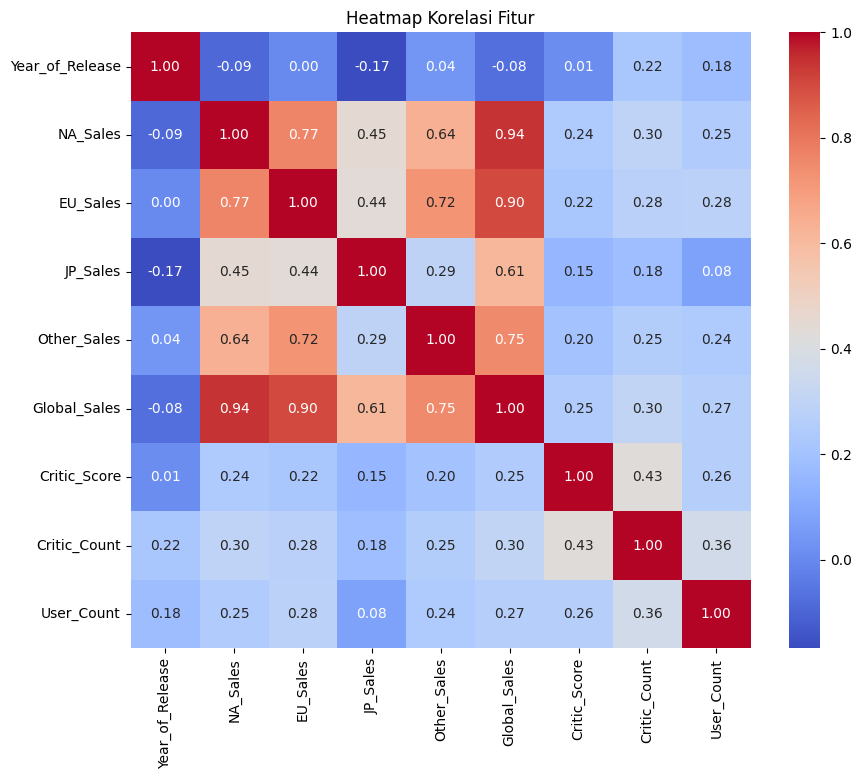

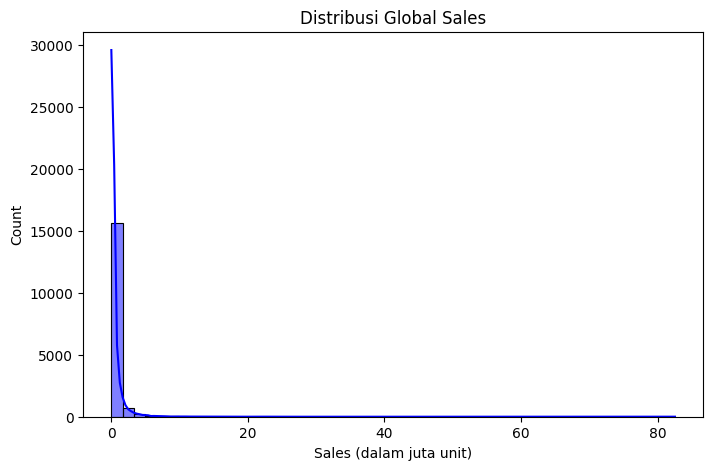

In [2]:
## 1. Exploratory Data Analysis (EDA)
##Tahap ini dilakukan untuk memahami karakteristik data melalui statistik deskriptif dan visualisasi untuk mendeteksi outlier serta korelasi antar fitur.
# Statistik Deskriptif
print("Statistik Deskriptif Data:")
display(df.describe())

# Visualisasi Wajib 1: Heatmap Korelasi
plt.figure(figsize=(10, 8))
# Hanya menggunakan kolom numerik untuk korelasi
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Fitur")
plt.show()

# Visualisasi Distribusi Target (Global Sales)
plt.figure(figsize=(8, 5))
sns.histplot(df['Global_Sales'], bins=50, kde=True, color='blue')
plt.title("Distribusi Global Sales")
plt.xlabel("Sales (dalam juta unit)")
plt.show()

In [3]:
## 2. Data Preprocessing
##Langkah ini sangat penting untuk membersihkan data dari nilai yang hilang (*missing values*) dan memastikan tipe data sesuai untuk pemodelan.
# 1. Menangani tipe data 'User_Score' yang berisi string 'tbd'
df['User_Score'] = df['User_Score'].replace('tbd', np.nan)
df['User_Score'] = df['User_Score'].astype(float)

# 2. Handling Missing Values
# menghapus baris yang memiliki nilai null pada fitur utama
df_clean = df.dropna(subset=['Global_Sales', 'Critic_Score', 'User_Score', 'Year_of_Release']).copy()

# 3. Encoding Variabel Kategorikal
# Menggunakan Label Encoding untuk 'Genre' sebagai contoh fitur bisnis tambahan
le = LabelEncoder()
df_clean['Genre_Encoded'] = le.fit_transform(df_clean['Genre'])

print(f"Data setelah pembersihan: {df_clean.shape[0]} baris.")



Data setelah pembersihan: 6894 baris.


In [5]:
## 3. Feature Engineering
##fitur baru bernama `Game_Age` untuk mengukur umur game sejak dirilis hingga tahun target saat ini (2026).
##Fitur ini membantu model memahami apakah umur rilis berpengaruh terhadap akumulasi penjualan.
# Pembuatan fitur baru
df_clean['Game_Age'] = 2026 - df_clean['Year_of_Release']

# Feature Scaling menggunakan StandardScaler
scaler = StandardScaler()
features_to_scale = ['Critic_Score', 'User_Score', 'Game_Age']
df_clean[features_to_scale] = scaler.fit_transform(df_clean[features_to_scale])

df_clean[['Name', 'Game_Age', 'Critic_Score', 'Global_Sales']].head()

,Name,Game_Age,Critic_Score,Global_Sales
0,Wii Sports,0.349922,0.414248,82.53
2,Mario Kart Wii,-0.122211,0.847146,35.52
3,Wii Sports Resort,-0.358277,0.702847,32.77
6,New Super Mario Bros.,0.349922,1.352194,29.80
7,Wii Play,0.349922,-0.884446,28.92


In [7]:
## 4. Pemodelan Regression
##Data dibagi menjadi 80% Latih dan 20% Uji.
##**Alasan pembagian 80:20:** Rasio ini memberikan porsi data latih yang cukup besar agar model dapat menangkap pola kompleks,
##sementara 20% tetap cukup sebagai data validasi yang objektif.
# Menyiapkan fitur
X_simple = df_clean[['Critic_Score']] # Simple Linear Regression
X_multi = df_clean[['Critic_Score', 'User_Score', 'Game_Age', 'Genre_Encoded']] # Multiple
y = df_clean['Global_Sales']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)
X_train_s, X_test_s, _, _ = train_test_split(X_simple, y, test_size=0.2, random_state=42)

# Model Simple Linear Regression
model_s = LinearRegression()
model_s.fit(X_train_s, y_train)
y_pred_s = model_s.predict(X_test_s)

# Model Multiple Linear Regression
model_m = LinearRegression()
model_m.fit(X_train, y_train)
y_pred_m = model_m.predict(X_test)

In [8]:
## 5. Evaluasi Model
##Kami menggunakan MAE, RMSE, dan R-squared untuk mengevaluasi performa model.
def print_metrics(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}\n")

print_metrics(y_test, y_pred_s, "Simple Linear Regression")
print_metrics(y_test, y_pred_m, "Multiple Linear Regression")

--- Simple Linear Regression ---
MAE  : 0.7862
RMSE : 1.5696
R2   : 0.0934

--- Multiple Linear Regression ---
MAE  : 0.7824
RMSE : 1.5571
R2   : 0.1077



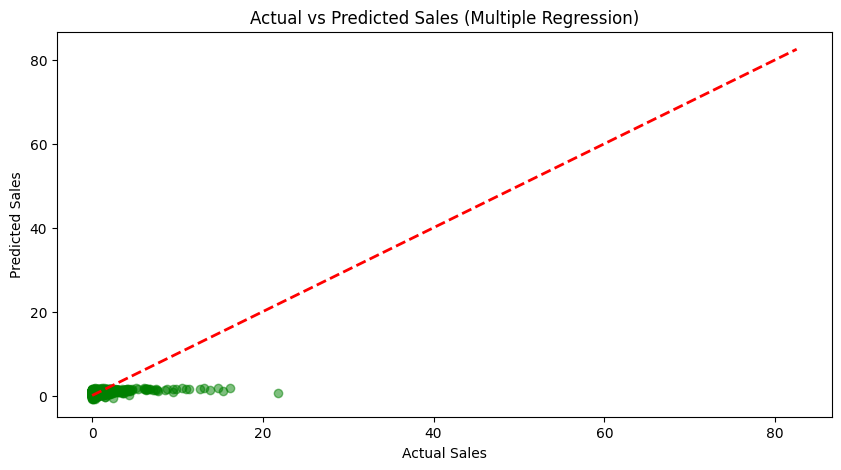

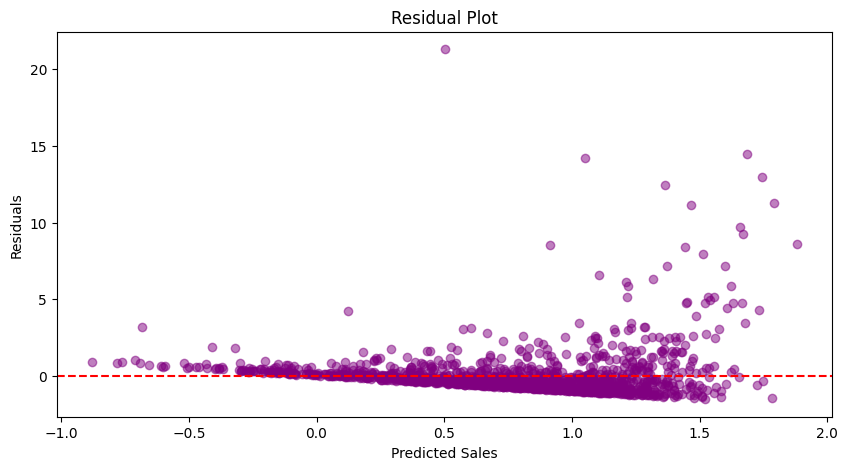

In [10]:
## 6. Analisis Prediksi dan Visualisasi
##Langkah terakhir adalah membandingkan nilai aktual vs prediksi serta melihat sebaran residual.
# Visualisasi Wajib 2: Scatter Plot (Actual vs Predicted)
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_m, alpha=0.5, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title("Actual vs Predicted Sales (Multiple Regression)")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.show()

# Visualisasi Wajib 3: Residual Plot
residuals = y_test - y_pred_m
plt.figure(figsize=(10, 5))
plt.scatter(y_pred_m, residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.show()